# Wind Speed and Gust as Indicators of Changing Weather

**Research Question:** *How closely are wind speed and gust related, and can sudden increases in gust strength signal unstable or changing weather conditions?*

This section examines whether `gust` provides useful information beyond average `wind_speed`, and whether it can help a Malaysian public weather information service communicate changing weather more clearly to the public.


## 1. Introduction, Variables, and Analysis Plan

### Introduction

Wind speed and gust are related but distinct measurements. **Wind speed** represents average air movement over an observation period, while **gust** records the strongest short-term increase in wind during that period.

A common public belief is that sudden strong gusts mean the weather is about to change, such as the arrival of rain or a storm. This analysis tests whether that idea is supported by the dataset.

### Variables Used

| Variable | Unit | Role in this analysis |
|---|---|---|
| `wind_speed` | m/s | Primary variable representing average wind conditions |
| `gust` | m/s | Primary variable representing short-term peak wind strength |
| `precipitation_rate` | mm/h | Supporting variable used to compare wind behaviour with wet weather |
| `pressure` | hPa | Supporting variable used to assess broader weather change |

A derived variable, **gust factor** = `gust / wind_speed` for observations where `wind_speed > 0`, is used to measure how much stronger gusts are relative to average wind conditions.

### Analysis Plan

This analysis proceeds in four steps:

1. Examine the basic relationship between `wind_speed` and `gust` using summary statistics and visualisation.
2. Explore the strength of gust behaviour using derived measures such as `gust_diff` and `gust_factor`.
3. Compare gust behaviour under dry and wet weather conditions to test whether stronger gusts are associated with rainfall.
4. Evaluate whether the results support using gust as a useful public indicator of unstable or changing weather.

### Expected Contribution to the Client

This section provides a practical answer on whether `wind_speed` and `gust` should be used as public indicators of changing weather, and whether gust should be treated as a key signal or only a supporting one.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

ROOT = Path.cwd()
DATA_PATH = ROOT / 'data' / 'malaysia_weather_data.csv'



In [2]:
def prepare_weather_subset(path: Path) -> pd.DataFrame:
    """Load the project dataset and prepare the wind-focused analysis table."""
    df = pd.read_csv(path)

    cols = ['pressure', 'wind_speed', 'gust', 'precipitation_rate']
    weather = df[cols].copy()

    weather = weather.dropna(subset=['wind_speed', 'gust']).copy()
    weather = weather[(weather['wind_speed'] >= 0) & (weather['gust'] >= 0)].copy()

    # Create simple indicators that match the research question.
    weather['wet_weather'] = weather['precipitation_rate'].fillna(0) > 0
    weather['gust_diff'] = weather['gust'] - weather['wind_speed']
    weather['gust_factor'] = np.where(weather['wind_speed'] > 0, weather['gust'] / weather['wind_speed'], np.nan)
    weather['high_gust'] = weather['gust'] >= weather['gust'].quantile(0.9)
    weather['high_gust_factor'] = weather['gust_factor'] >= weather['gust_factor'].quantile(0.9)

    return weather

raw_df = pd.read_csv(DATA_PATH)
analysis_df = prepare_weather_subset(DATA_PATH)

missing_summary = raw_df[['wind_speed', 'gust', 'pressure', 'precipitation_rate']].isna().sum().rename('missing_count').to_frame()

print(f'Original rows: {len(raw_df):,}')
print(f'Rows kept for wind/gust analysis: {len(analysis_df):,}')
print(f'Share of original rows kept: {len(analysis_df) / len(raw_df):.1%}')
print()
print('Missing values in key variables before cleaning:')
display(missing_summary)
print('Preview of the prepared analysis table:')
display(analysis_df.head())


Original rows: 57,475
Rows kept for wind/gust analysis: 44,191
Share of original rows kept: 76.9%

Missing values in key variables before cleaning:


,missing_count
wind_speed,8642
gust,13284
pressure,8190
precipitation_rate,10901


Preview of the prepared analysis table:


,pressure,wind_speed,gust,precipitation_rate,wet_weather,gust_diff,gust_factor,high_gust,high_gust_factor
0,"1,015.325",0.900,1.500,0.000,False,0.600,1.667,False,False
1,"1,000.680",5.200,5.300,0.000,False,0.100,1.019,False,False
2,"1,013.550",0.000,0.000,0.000,False,0.000,NaN,False,False
3,"1,005.420",0.000,0.000,0.000,False,0.000,NaN,False,False
4,"1,007.790",6.400,16.100,0.000,False,9.700,2.516,True,False


## 2. Data Cleaning and Feature Engineering

The analysis keeps observations where `wind_speed`, `gust`, and the reconstructed timestamp are available. Negative wind values are also excluded. This ensures that each row can be interpreted consistently in later comparisons.

The notebook creates two gust-related indicators:

- **`gust_diff`** to measure the absolute increase from average wind to peak wind
- **`gust_factor`** to measure the relative jump from average wind to gust

These features are useful because the client does not only need to know whether wind is strong; they need to know whether the wind is **becoming unusually erratic or unstable**.


In [3]:
cleaning_summary = pd.DataFrame({
    'metric': [
        'Rows in raw dataset',
        'Rows after requiring wind_speed and gust',
        'Rows flagged as wet weather',
        'Rows with valid gust_factor',
        'Median wind_speed (m/s)',
        'Median gust (m/s)',
        'Median gust_diff (m/s)',
        'Median gust_factor'
    ],
    'value': [
        len(raw_df),
        len(analysis_df),
        int(analysis_df['wet_weather'].sum()),
        int(analysis_df['gust_factor'].notna().sum()),
        analysis_df['wind_speed'].median(),
        analysis_df['gust'].median(),
        analysis_df['gust_diff'].median(),
        analysis_df['gust_factor'].median(),
    ]
})

display(cleaning_summary)


,metric,value
0,Rows in raw dataset,"57,475.000"
1,Rows after requiring wind_speed and gust,"44,191.000"
2,Rows flagged as wet weather,"2,240.000"
3,Rows with valid gust_factor,"29,207.000"
4,Median wind_speed (m/s),0.800
5,Median gust (m/s),1.600
6,Median gust_diff (m/s),0.600
7,Median gust_factor,1.545


### Section Conclusion

The data preparation step keeps only observations with usable wind and time information, then creates `gust_diff` and `gust_factor` to describe sudden changes in wind strength more clearly. This gives the later analysis a clean and relevant subset of the dataset for answering the research question.


## 3. Analysis 1: Relationship Between Wind Speed and Gust

The first test is straightforward: if `wind_speed` and `gust` are closely related, they should move together strongly across observations. A strong relationship would mean gust often acts as a sharper version of the same wind pattern, rather than as a completely separate phenomenon.


,metric,value
0,Correlation between wind_speed and gust,0.934
1,Proportion of rows where gust >= wind_speed,1.000
2,Median wind_speed (m/s),0.800
3,Median gust (m/s),1.600


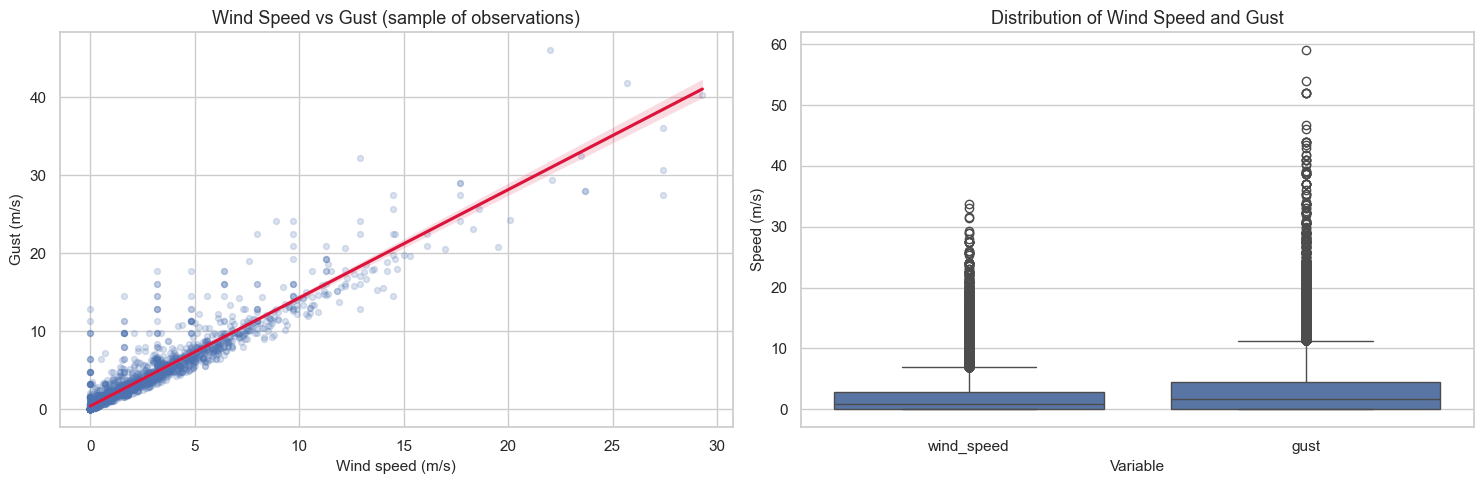

In [4]:
correlation = analysis_df['wind_speed'].corr(analysis_df['gust'])
prop_gust_ge_wind = (analysis_df['gust'] >= analysis_df['wind_speed']).mean()
relationship_summary = pd.DataFrame({
    'metric': [
        'Correlation between wind_speed and gust',
        'Proportion of rows where gust >= wind_speed',
        'Median wind_speed (m/s)',
        'Median gust (m/s)'
    ],
    'value': [
        correlation,
        prop_gust_ge_wind,
        analysis_df['wind_speed'].median(),
        analysis_df['gust'].median()
    ]
})

display(relationship_summary)

# Use a sample so the scatter plot stays readable in the notebook.
sample_df = analysis_df.sample(n=min(3000, len(analysis_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(
    data=sample_df,
    x='wind_speed',
    y='gust',
    scatter_kws={'alpha': 0.2, 's': 18},
    line_kws={'color': 'crimson'},
    ax=axes[0]
)
axes[0].set_title('Wind Speed vs Gust (sample of observations)')
axes[0].set_xlabel('Wind speed (m/s)')
axes[0].set_ylabel('Gust (m/s)')

sns.boxplot(
    data=analysis_df[['wind_speed', 'gust']].melt(var_name='variable', value_name='value'),
    x='variable',
    y='value',
    ax=axes[1]
)
axes[1].set_title('Distribution of Wind Speed and Gust')
axes[1].set_xlabel('Variable')
axes[1].set_ylabel('Speed (m/s)')

plt.tight_layout()
plt.show()

### Section Conclusion

`wind_speed` and `gust` are **very closely related** in this dataset. The correlation is approximately **0.93**, which indicates a strong positive relationship. Gust is also greater than or equal to average wind in almost every valid observation.

For the client, this means gust is not a random or isolated measure. It usually reflects the same wind pattern as `wind_speed`, but in a more intense form that may be easier for the public to notice.


## 4. Analysis 2: How Large Are Gust Increases?

A strong correlation alone does not answer whether gusts are useful as an instability signal. The next step is to measure **how much** gust exceeds average wind, and whether that difference is large enough to matter in public communication.

This section uses `gust_diff` and `gust_factor` to show how much stronger gusts typically are than average wind conditions.


,metric,value
0,Median gust_diff (m/s),0.600
1,Mean gust_diff (m/s),1.165
2,Median gust_factor,1.545
3,Mean gust_factor,1.943
4,90th percentile gust_factor,3.000


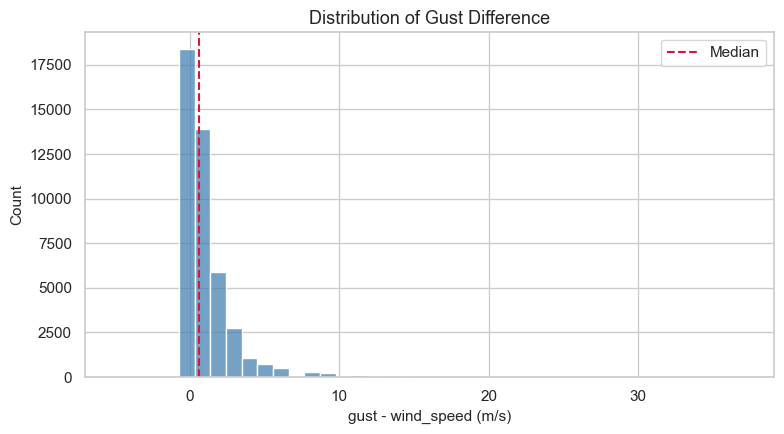

In [5]:
gust_strength_summary = pd.DataFrame({
    'metric': [
        'Median gust_diff (m/s)',
        'Mean gust_diff (m/s)',
        'Median gust_factor',
        'Mean gust_factor',
        '90th percentile gust_factor'
    ],
    'value': [
        analysis_df['gust_diff'].median(),
        analysis_df['gust_diff'].mean(),
        analysis_df['gust_factor'].median(),
        analysis_df['gust_factor'].mean(),
        analysis_df['gust_factor'].quantile(0.9)
    ]
})

display(gust_strength_summary)

plt.figure(figsize=(8, 4.5))
sns.histplot(analysis_df['gust_diff'], bins=40, color='steelblue')
plt.axvline(analysis_df['gust_diff'].median(), color='crimson', linestyle='--', label='Median')
plt.title('Distribution of Gust Difference')
plt.xlabel('gust - wind_speed (m/s)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


### Section Conclusion

The median `gust_diff` is about **0.6 m/s**, while the median `gust_factor` is about **1.55**. In practical terms, this means gust is often about **50% stronger** than the average wind reading when wind is present.

This matters for the client because gust captures the **felt sharpness** of wind conditions. It can help communicate short-lived wind risk better than average wind alone, especially when conditions feel more erratic than a simple mean wind speed suggests.


## 5. Analysis 3: Do Stronger Gusts Align With Wet Weather?

To test whether gust can act as a weather-change signal, this section compares gust behaviour between **dry** and **wet** observations. If gust is a reliable warning sign, wet-weather conditions should show noticeably stronger gust behaviour.


wind_speed         gust        gust_factor         pressure  \
                  mean median  mean median        mean median      mean   
wet_weather                                                               
False            1.969  0.800 3.122  1.600       1.940  1.545 1,010.765   
True             2.213  1.000 3.607  1.800       2.005  1.556 1,010.447   

                      precipitation_rate         
               median               mean median  
wet_weather                                      
False       1,011.180              0.000  0.000  
True        1,010.670              7.142  1.800

,group,wet_weather_rate
0,All observations,0.051
1,Top 10% gust,0.064
2,Top 10% gust_factor,0.060


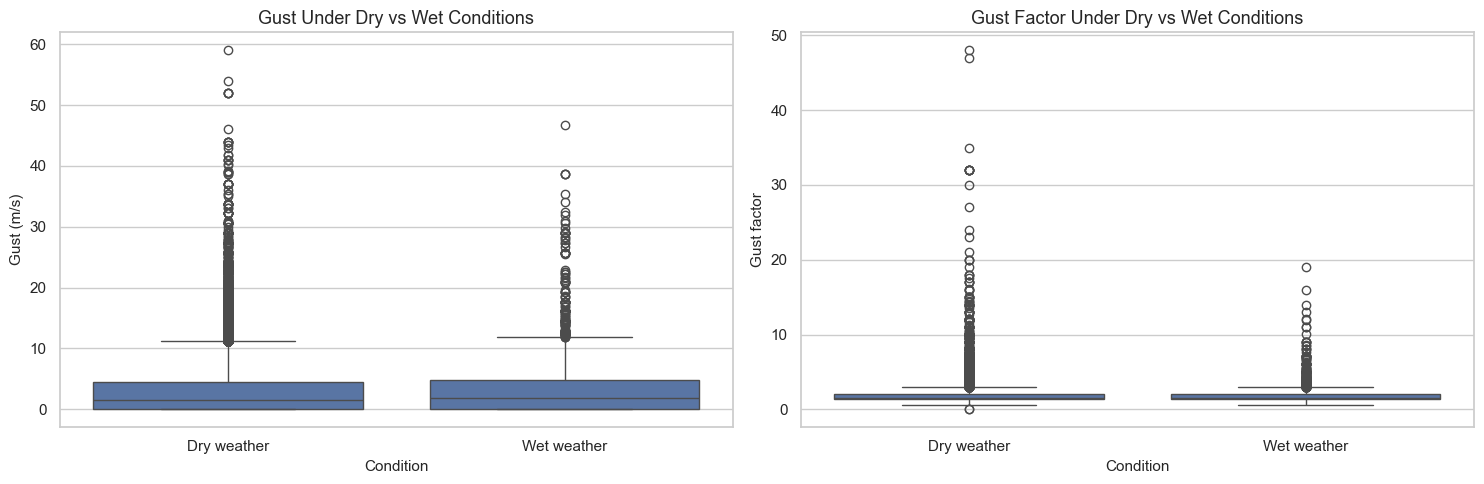

In [6]:
condition_labels = np.where(analysis_df['wet_weather'], 'Wet weather', 'Dry weather')
plot_df = analysis_df.assign(condition=condition_labels)

wet_summary = (
    analysis_df.groupby('wet_weather')[['wind_speed', 'gust', 'gust_factor', 'pressure', 'precipitation_rate']]
    .agg(['mean', 'median'])
    .round(3)
)

top_decile_rates = pd.DataFrame({
    'group': ['All observations', 'Top 10% gust', 'Top 10% gust_factor'],
    'wet_weather_rate': [
        analysis_df['wet_weather'].mean(),
        analysis_df.loc[analysis_df['high_gust'], 'wet_weather'].mean(),
        analysis_df.loc[analysis_df['high_gust_factor'], 'wet_weather'].mean()
    ]
})

display(wet_summary)
display(top_decile_rates)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=plot_df, x='condition', y='gust', ax=axes[0])
axes[0].set_title('Gust Under Dry vs Wet Conditions')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Gust (m/s)')

sns.boxplot(data=plot_df[plot_df['gust_factor'].notna()], x='condition', y='gust_factor', ax=axes[1])
axes[1].set_title('Gust Factor Under Dry vs Wet Conditions')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Gust factor')

plt.tight_layout()
plt.show()

### Section Conclusion

Wet-weather observations do show slightly stronger gust behaviour, but the increase is **modest rather than dramatic**. The wet-weather rate rises from about **4.9%** in the rest of the data to about **6.4%** among the top 10% of gust readings, and to about **6.0%** among the top 10% of gust-factor readings.

For the client, this suggests gust is **not a strong standalone warning of rainfall or weather change**. It contains some useful signal, but the effect is weak enough that gust should be interpreted alongside other indicators rather than used by itself.


## 6. Final Answer for the Client

### Main findings

- `wind_speed` and `gust` are **strongly related**, with a correlation of about **0.93**.
- Gust usually represents a **more intense version of the same wind pattern**, rather than a separate weather signal.
- Gust is often materially higher than average wind, so it is useful for describing **short-term wind risk**.
- However, stronger gust behaviour is only **weakly associated** with wet weather.

### Recommendation

For public weather communication, the client should treat **gust as a supporting indicator of unstable wind conditions**, not as a standalone predictor of changing weather or imminent rainfall.

A practical communication strategy would be:

1. Use `wind_speed` to describe the overall wind conditions.
2. Use `gust` to warn the public when winds may feel suddenly stronger or more erratic.
3. Combine gust with rainfall and pressure-related indicators when communicating broader weather change.

### Limitation

This notebook uses observational weather data rather than a forecasting model, so the results support **communication guidance** rather than formal prediction. Stronger predictive claims would require a more explicit event-based forecasting setup.
